In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt

In [ ]:
search_result = lk.search_lightcurve("Kepler-10",mission = "Kepler")
print(search_result)

In [ ]:
lc = search_result[0].download() # 1/4 of data from NASA
print(lc)

In [ ]:
lc.plot()
plt.show()

In [ ]:
lc_clean=lc.remove_outliers(sigma=3)
lc_clean.plot()
plt.show()

In [ ]:
lc_flat, trend = lc_clean.flatten(return_trend = True)
lc_flat.plot()
plt.show()

In [ ]:
fig, axes = plt.subplots(2,1,figsize = (10,8))
lc_clean.plot(ax = axes[0], title ="before flatten")
lc_flat.plot(ax = axes[1], title = "after flatten")
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
lc_flat.plot()
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
plt.ylim(0.998,1.002)
plt.show()

In [ ]:
period = 0.8375243
lc_folded = lc_flat.fold(period = period)
lc_folded.plot()
plt.show()

In [112]:
# Download all data from NASA
lc_all = search_result.download_all()
lc_stitched = lc_all.stitch()

# Clean and flatten
lc_stitched_clean = lc_stitched.remove_outliers(sigma=3)
lc_stitched_flat, trend = lc_stitched_clean.flatten(return_trend=True)

# Fold and bin
lc_folded = lc_stitched_flat.fold(period=0.8375243)
lc_binned = lc_folded.bin(time_bin_size=0.001)
lc_binned.plot()
plt.show()

KeyboardInterrupt: 

In [ ]:
print(lc_binned)


In [ ]:
lc_binned.plot()
plt.ylim(0.9985, 1.0005)
plt.show()


In [ ]:
lc_binned.plot()
plt.ylim(0.9996, 1.0002)
plt.show()

In [ ]:
lc_binned.plot()
plt.ylim(0.99985, 1.00015)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
print(lc_folded.flux.mean())
print(lc_folded.flux.min())
print(lc_folded.flux.max())

In [ ]:
lc_folded = lc_stitched_flat.fold(period=0.8375243, epoch_time=2454833.024)
lc_binned = lc_folded.bin(time_bin_size=0.0005)
lc_binned.plot()
plt.ylim(0.9984, 1.0005)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()

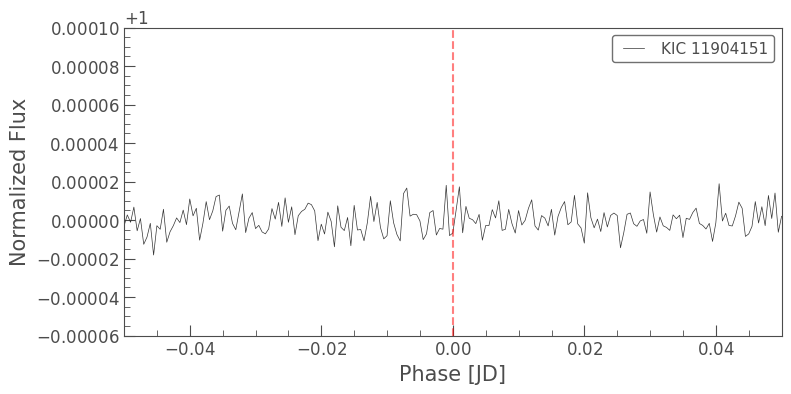

In [ ]:
lc_binned.plot()
plt.ylim(0.99994, 1.0001)
plt.xlim(-0.05, 0.05)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.show()
# see dip at x = 0!

In [117]:
import numpy as np
baseline = lc_binned.flux.mean()
dip = lc_binned.flux.min()
dip_depth = baseline - dip
print(f"Dip depth: {dip_depth:.6f}")
print(f"Fractional dip: {dip_depth/baseline:.6f}")

Dip depth: 0.000026
Fractional dip: 0.000026


In [120]:
transit_mask = (lc_binned.time.value > -0.03) & (lc_binned.time.value < 0.03)
transit_flux = lc_binned.flux[transit_mask]

print(f"Transit flux mean: {transit_flux.mean():.8f}")
print(f"Baseline: {lc_binned.flux.mean():.8f}")
print(f"Dip depth: {(lc_binned.flux.mean() - transit_flux.mean()):.8f}")

Transit flux mean: 1.00000013
Baseline: 1.00000018
Dip depth: 0.00000005


In [121]:
print(lc_binned.time.value[:20])

[-0.41851143 -0.41801143 -0.41751143 -0.41701143 -0.41651143 -0.41601143
 -0.41551143 -0.41501143 -0.41451143 -0.41401143 -0.41351143 -0.41301143
 -0.41251143 -0.41201143 -0.41151143 -0.41101143 -0.41051143 -0.41001143
 -0.40951143 -0.40901143]


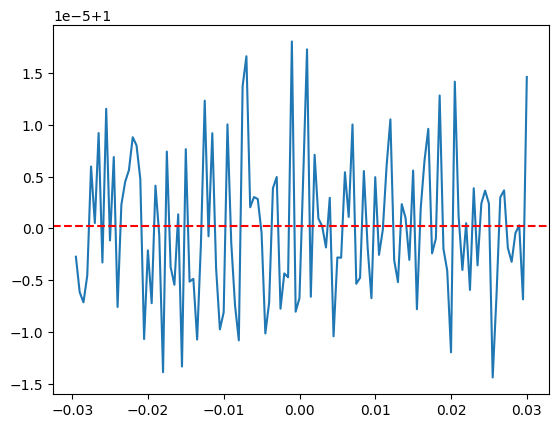

In [122]:
transit_mask = (lc_binned.time.value > -0.03) & (lc_binned.time.value < 0.03)
transit_flux = lc_binned.flux[transit_mask]
transit_time = lc_binned.time.value[transit_mask]

plt.plot(transit_time, transit_flux)
plt.axhline(y=lc_binned.flux.mean(), color='red', linestyle='--')
plt.show()

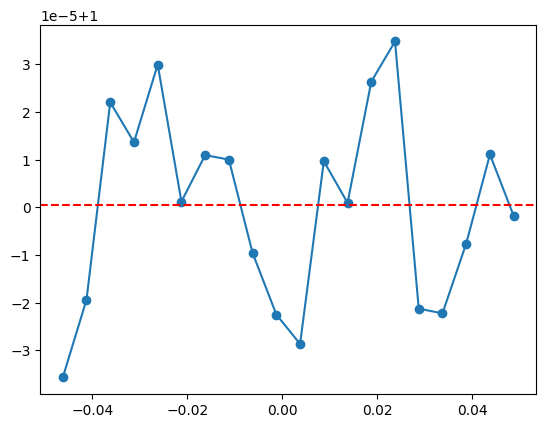

In [123]:
lc_binned_coarse = lc_folded.bin(time_bin_size=0.005)

transit_mask = (lc_binned_coarse.time.value > -0.05) & (lc_binned_coarse.time.value < 0.05)
transit_flux = lc_binned_coarse.flux[transit_mask]
transit_time = lc_binned_coarse.time.value[transit_mask]

plt.plot(transit_time, transit_flux, 'o-')
plt.axhline(y=lc_binned_coarse.flux.mean(), color='red', linestyle='--')
plt.show()

In [124]:
print(lc_folded)

        time              flux      ...   pos_corr1      pos_corr2   
                                    ...      pix            pix      
-------------------- -------------- ... -------------- --------------
 -0.4187302665535485  9.9977858e-01 ... -1.8068411e-03  1.0112738e-02
 -0.4187162387622536  1.0000574e+00 ... -6.3456404e-03  2.6127663e-02
 -0.4187147690994443  1.0000095e+00 ...  1.7899018e-02 -3.2646049e-02
 -0.4187016997401533  9.9974966e-01 ...  4.3588975e-03 -1.3561223e-02
-0.41865673737105136  9.9993204e-01 ... -4.0757196e-04  3.8815988e-03
 -0.4186391541104412  9.9991654e-01 ...  7.4914051e-03 -1.9077040e-02
 -0.4186337818051429  9.9990773e-01 ... -4.3357606e-03  2.0235457e-02
-0.41863373386418523  9.9995715e-01 ... -8.6248647e-03  3.6231969e-02
-0.41858587607848585  1.0000492e+00 ...  2.9626788e-04 -3.1524766e-03
                 ...            ... ...            ...            ...
   0.418574087492776  9.9992488e-01 ...  3.8335943e-03 -1.0585669e-02
 0.41861623866468656

In [ ]:
# Known values for Kepler-10
transit_depth = 0.000152        # fractional dip depth
R_star = 1.065                  # radius of Kepler-10 in solar radii
R_sun = 696340                  # km

# Calculate planet radius
# depth = (Rp/Rs)^2
# Rp = Rs * sqrt(depth)

R_planet_solar = R_star * np.sqrt(transit_depth)
R_planet_km = R_planet_solar * R_sun
R_earth = 6371                  # km

R_planet_earth = R_planet_km / R_earth

print(f"Planet radius: {R_planet_solar:.4f} solar radii")
print(f"Planet radius: {R_planet_km:.0f} km")
print(f"Planet radius: {R_planet_earth:.2f} Earth radii")

Planet radius: 0.0131 solar radii
Planet radius: 9143 km
Planet radius: 1.44 Earth radii
